In [ ]:
# !pip install -q transformers datasets librosa soundfile accelerate

In [ ]:
import time
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

In [ ]:
audio_path = "voice-sample.wav"

audio, sr = librosa.load(
    audio_path,
    sr=16000
)

duration = len(audio) / sr

print("Sample Rate:", sr)
print("Duration:", duration, "seconds")

Sample Rate: 16000
Duration: 26.3 seconds


In [ ]:
audio = audio[:10 * sr]

duration = len(audio) / sr

print("Audio duration:", duration, "seconds")

Audio duration: 10.0 seconds


#Whisper Tiny

In [ ]:
whisper_tiny = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-tiny",
    chunk_length_s=30
)

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [ ]:
start_time = time.time()

result_tiny = whisper_tiny(audio)

end_time = time.time()

tiny_time = end_time - start_time

tiny_text = result_tiny["text"]

In [ ]:
print("Whisper Tiny:")
print(tiny_text)

print("Inference Time:", round(tiny_time, 3), "seconds")

Whisper Tiny:
 Hi there, this is a sample voice recording created for speech synthesis testing. The quick brown fox jumps over the lazy dog. Just a fun way.
Inference Time: 5.082 seconds


In [ ]:
tiny_rtf = tiny_time / duration

print("Whisper Tiny RTF:", round(tiny_rtf, 3))

Whisper Tiny RTF: 0.508




---



#Whisper Base

In [ ]:
whisper_base = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base",
    chunk_length_s=30
)

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [ ]:
start_time = time.time()

result_base = whisper_base(audio)

end_time = time.time()

base_time = end_time - start_time

base_text = result_base["text"]

In [ ]:
print("Whisper Base:")
print(base_text)

print("Inference Time:", round(base_time, 3), "seconds")

Whisper Base:
 Hi there, this is a sample voice recording created for speech synthesis testing. The quit brown fox jumps over the lazy dog. Just a fun way
Inference Time: 8.824 seconds


In [ ]:
base_rtf = base_time / duration

print("Whisper Base RTF:", round(base_rtf, 3))

Whisper Base RTF: 0.882


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Whisper Tiny",
        "Whisper Base"
    ],
    "Inference Time (seconds)": [
        tiny_time,
        base_time
    ],
    "RTF": [
        tiny_rtf,
        base_rtf
    ],
    "Transcription": [
        tiny_text,
        base_text
    ]
})

results

,Model,Inference Time (seconds),RTF,Transcription
0,Whisper Tiny,5.08164,0.508164,"Hi there, this is a sample voice recording cr..."
1,Whisper Base,8.82390,0.882390,"Hi there, this is a sample voice recording cr..."


In [ ]:
if tiny_time < base_time:
    print("Whisper Tiny is faster.")
else:
    print("Whisper Base is faster.")

Whisper Tiny is faster.


In [ ]:
speed_difference = base_time / tiny_time

print(
    f"Whisper Tiny is approximately "
    f"{speed_difference:.2f}x faster than Whisper Base."
)

Whisper Tiny is approximately 1.74x faster than Whisper Base.




---



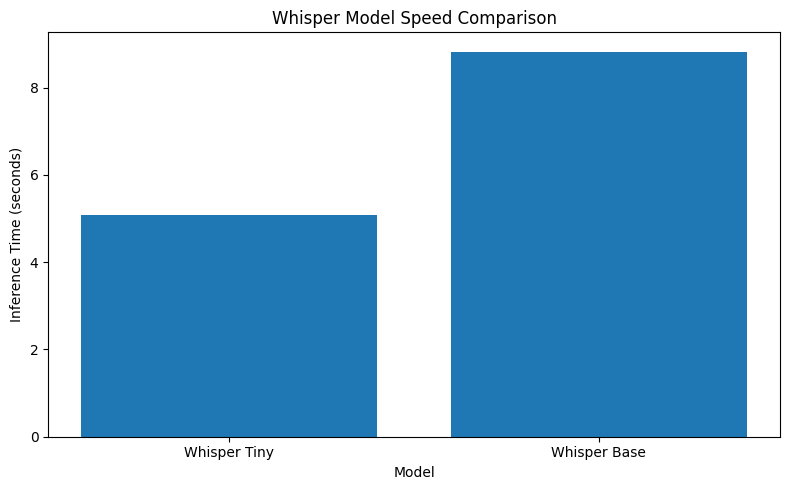

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Inference Time (seconds)"]
)

plt.title("Whisper Model Speed Comparison")
plt.xlabel("Model")
plt.ylabel("Inference Time (seconds)")

plt.tight_layout()

plt.savefig(
    "whisper_speed_comparison.png",
    dpi=300
)

plt.show()